# Fig 5J

In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(dplyr)
  require(tidyr)
  library(reshape2)
})

In [2]:
plasma_longitudinal_comparisons <- fread('../../data/figure-inputs/olink/plasma_longitudinal_pairwise_deps.csv')
plasma_healthy_comparisons <- fread('../../data/figure-inputs/olink/plasma_longitudinal_comparisons_to_healthy.csv')
bm_longitudinal_comparisons <- fread('../../data/figure-inputs/olink/boneMarrow_longitudinal_pairwise_deps.csv')

Warning message:
“Removed 1434 rows containing non-finite outside the scale range (`stat_cor()`).”


Warning message:
“Removed 1434 rows containing missing values or values outside the scale range (`geom_point()`).”


Warning message:
“Removed 1434 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


Warning message:
“ggrepel: 1423 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“Removed 1434 rows containing non-finite outside the scale range (`stat_cor()`).”


Warning message:
“Removed 1434 rows containing missing values or values outside the scale range (`geom_point()`).”


Warning message:
“Removed 1434 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


Warning message:
“ggrepel: 1412 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


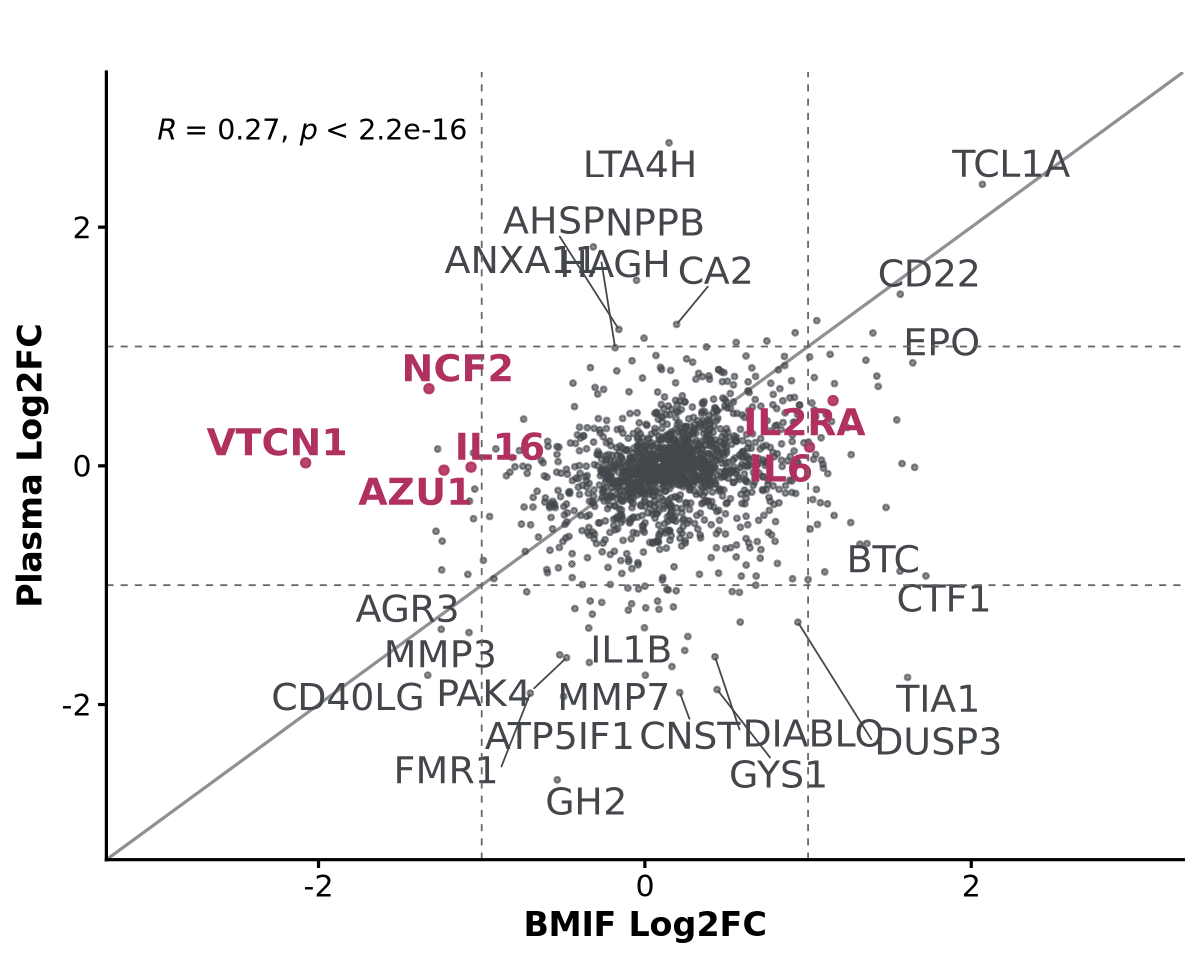

In [3]:
bm_longitudinal_comparisons$Tissue = 'BM'
plasma_longitudinal_comparisons$Tissue = 'Plasma'
combined_results <- rbind(bm_longitudinal_comparisons, 
      plasma_longitudinal_comparisons)

effects <- combined_results[, c('Log2FC','Assay','Tissue','Contrast')]
effects$Contrast <- gsub('ASCT60d','ASCT60_90d', effects$Contrast)
effects$Contrast <- gsub('ASCT90d','ASCT60_90d',  effects$Contrast)

deps <- c("AZU1", "NCF2", "VTCN1", "IL16", "IL2RA", "IL6")

plot_correlations <- function(contrast, deps = NULL) {
  tmp <- dcast(effects[Contrast == contrast],
    formula = Assay ~ Tissue + Contrast,
    value.var = "Log2FC", fun.aggregate = mean
  )
  tmp$Var1 <- tmp[, 2]
  tmp$Var2 <- tmp[, 3]
  tmp$highlight <- if (!is.null(deps)) tmp$Assay %in% deps else FALSE
  tmp_label <- tmp[tmp$highlight, ]
  tmp_other <- tmp[!tmp$highlight, ]

  p <- ggplot(tmp, aes(x = Var1, y = Var2, label = Assay)) +
    geom_point(data = tmp_other, alpha = 0.6, size = 1, color = "#43464B") +
    geom_point(data = tmp_label, alpha = 0.9, size = 2, color = "maroon") +
    geom_abline(color = "#43464B", alpha = 0.6) +
    ggrepel::geom_text_repel(
      data = tmp_other,
      size = 8,
      color = "#43464B",
      max.overlaps = 50,
      min.segment.length = 1,
      show.legend = FALSE
    ) +
    ggrepel::geom_text_repel(
      data = tmp_label,
      size = 8,
      fontface = 'bold',
      color = "maroon",
      max.overlaps = 50,
      min.segment.length = 1,
      show.legend = FALSE
    ) +
    ggpubr::stat_cor(method = "spearman", size = 6, color = "black") +
    labs(x = "BMIF", y = "Plasma") +
    theme_classic(base_size = 22) +
    theme(
      axis.text = element_text(size = 20),
      axis.title = element_text(size = 22)
    )
  return(list(Plot = p, df = tmp))
}

options(repr.plot.width = 10, repr.plot.height = 8)
p <- plot_correlations('EI-ASCT1y', deps = deps)$Plot +
  xlab('BMIF Log2FC') +
  ylab('Plasma Log2FC') +
  ggtitle('') +
  theme_classic(base_size = 20) +
  theme(
    text = element_text(size = 20),
    axis.title = element_text(size = 20, face = "bold"),
    axis.text = element_text(size = 18),
    plot.margin = margin(10, 10, 10, 10)
  ) +
  xlim(-3, 3) +
  ylim(-3, 3) +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "gray40", linewidth = 0.5) +
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "gray40", linewidth = 0.5)

p
ggsave("../../data/figure-outputs/figure-5/fig_5j.pdf", plot = p, width = 10, height = 8, dpi = 200, device = cairo_pdf)